In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [41]:
df = pd.read_csv("../data/base_tratada.csv", sep=",")

In [42]:
df.head(2)

,EndToEndId,Valor,TipoChave,Status,Anomalia,DataHora_Tratada,Hora,DiaDaSemana,FimDeSemana,Horario_Comercial,Madrugada,Dia_do_Mes,Dia_de_Pagamento,Valor_Redondo,Status_Pendente,Mesmo_Banco,Valor_Log,Valor_std,Valor_Log_std,Hora_std
0,f094cb2c-2a73-463c-b60e-0c57262051e4,4658.86,Telefone,Concluída,0,2025-06-26 21:07:56,21,3,0,0,0,26,0,0,0,0,8.446741,1.479006,0.901857,1.353532
1,f0409769-741f-49bd-811a-3842cc8f54db,3184.72,Telefone,Pendente,0,2025-06-23 17:47:56,17,0,0,1,0,23,0,0,1,0,8.066434,0.466666,0.537437,0.778973


In [43]:
var_cat = [
    'Madrugada',
    'Dia_do_Mes',
    'Dia_de_Pagamento',
    'Valor_Redondo',
    'Status_Pendente',
    'Mesmo_Banco',
    'DiaDaSemana',
    'FimDeSemana',
    'Horario_Comercial',
    'TipoChave',
    'Status'
]

var_num = [
    'Valor', 'Hora'
]

var_ignored = [
    'EndToEndId',
    'DataHora_Tratada',
    'Anomalia'
]

## Análise Variáveis Numéricas

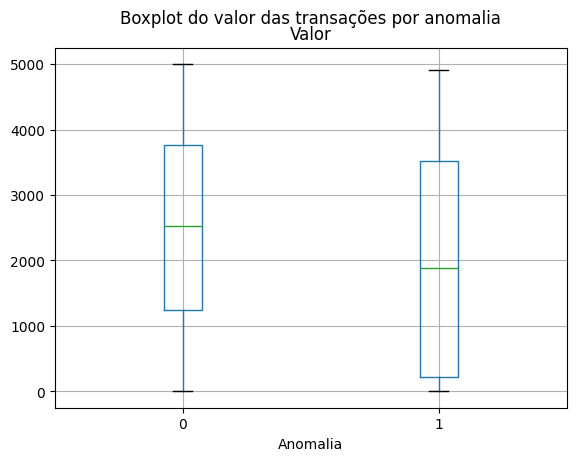

In [44]:
df.boxplot(
    column=['Valor'],
    by='Anomalia'
)

plt.suptitle('Boxplot do valor das transações por anomalia')
plt.show()

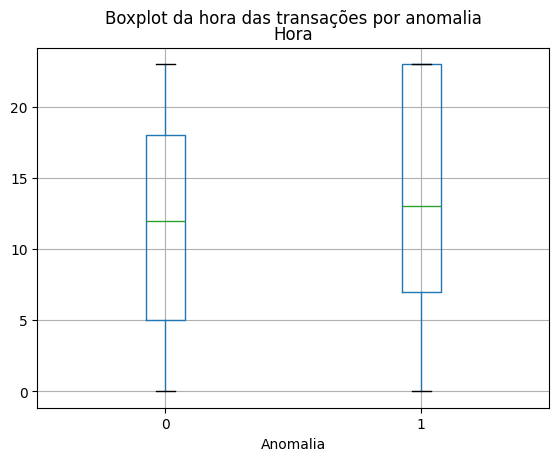

In [45]:
df.boxplot(
    column=['Hora'],
    by='Anomalia'
)

plt.suptitle('Boxplot da hora das transações por anomalia')
plt.show()

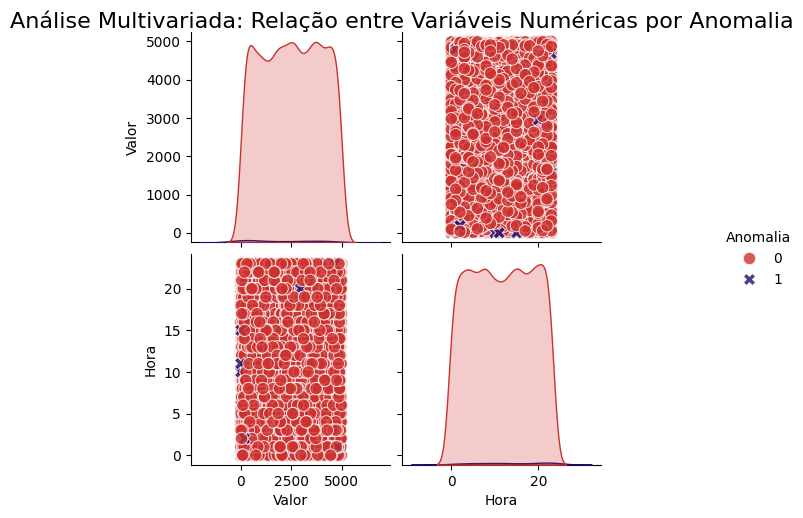

In [46]:
g = sns.pairplot(
    data=df,
    vars=var_num,
    hue='Anomalia', 
    palette={0: '#cc312e', 1: '#1d0a6a'},
    markers=["o", "X"], # Bolinha para o normal, 'X' para a anomalia
    diag_kind='kde', 
    plot_kws={'alpha': 0.8, 's': 80} 
)

g.fig.suptitle('Análise Multivariada: Relação entre Variáveis Numéricas por Anomalia', y=1.02, fontsize=16)

plt.show()

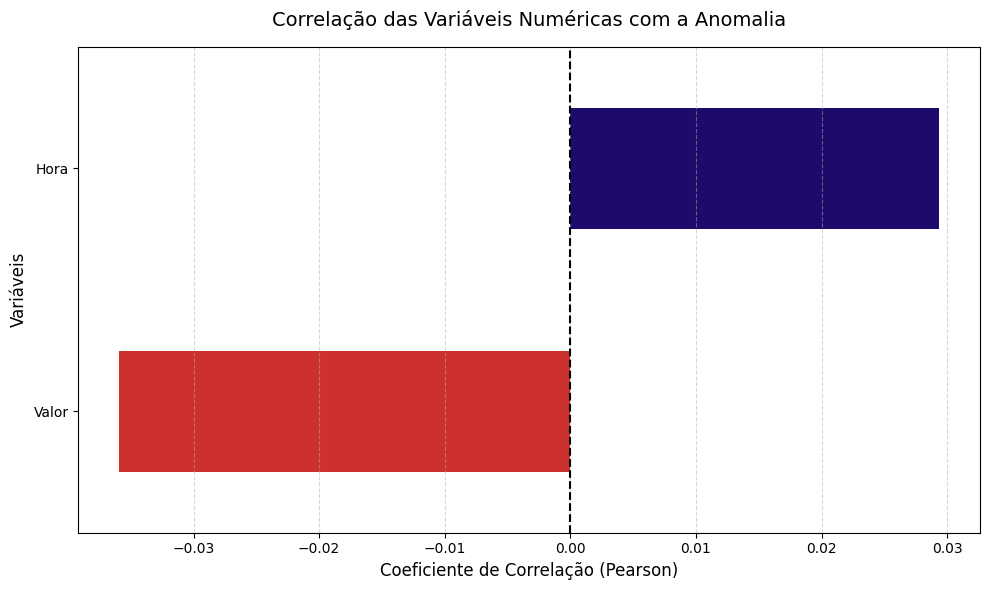

In [47]:
correlacoes = df[var_num+['Anomalia']].corr()
corr_com_alvo = correlacoes['Anomalia'].drop('Anomalia').sort_values()

plt.figure(figsize=(10, 6))

cores = ['#1d0a6a' if valor > 0 else '#cc312e' for valor in corr_com_alvo.values]

corr_com_alvo.plot(kind='barh', color=cores)

plt.title('Correlação das Variáveis Numéricas com a Anomalia', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlação (Pearson)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)

plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [48]:
print("\n--- Tabela de Correlação Exata ---")
print(corr_com_alvo.sort_values(ascending=False))
print("\n--- Matriz de Correlação Completa ---")
print(correlacoes)


--- Tabela de Correlação Exata ---
Hora     0.029351
Valor   -0.035901
Name: Anomalia, dtype: float64

--- Matriz de Correlação Completa ---
             Valor      Hora  Anomalia
Valor     1.000000  0.013467 -0.035901
Hora      0.013467  1.000000  0.029351
Anomalia -0.035901  0.029351  1.000000


## Análise Variáveis Categóricas

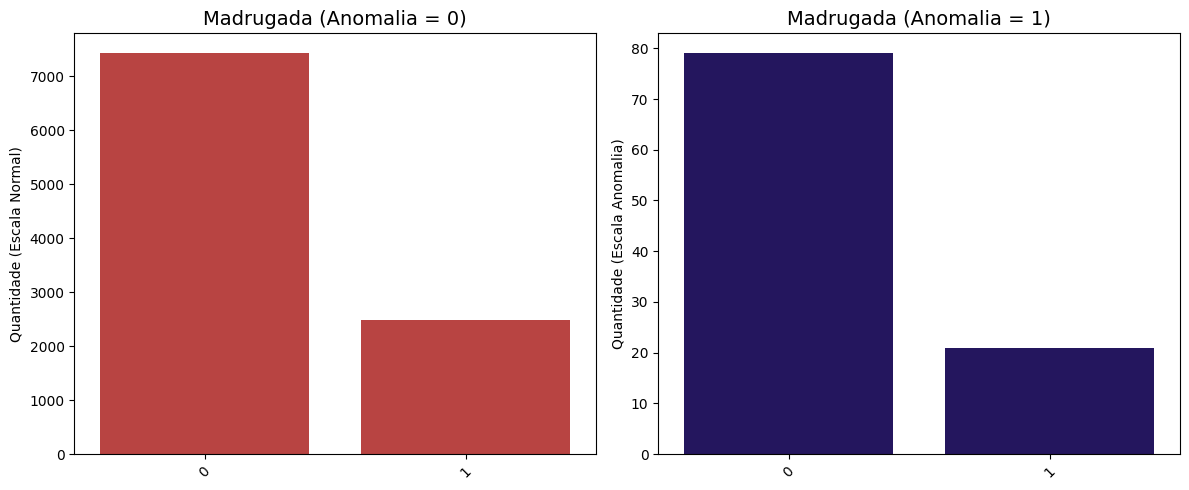

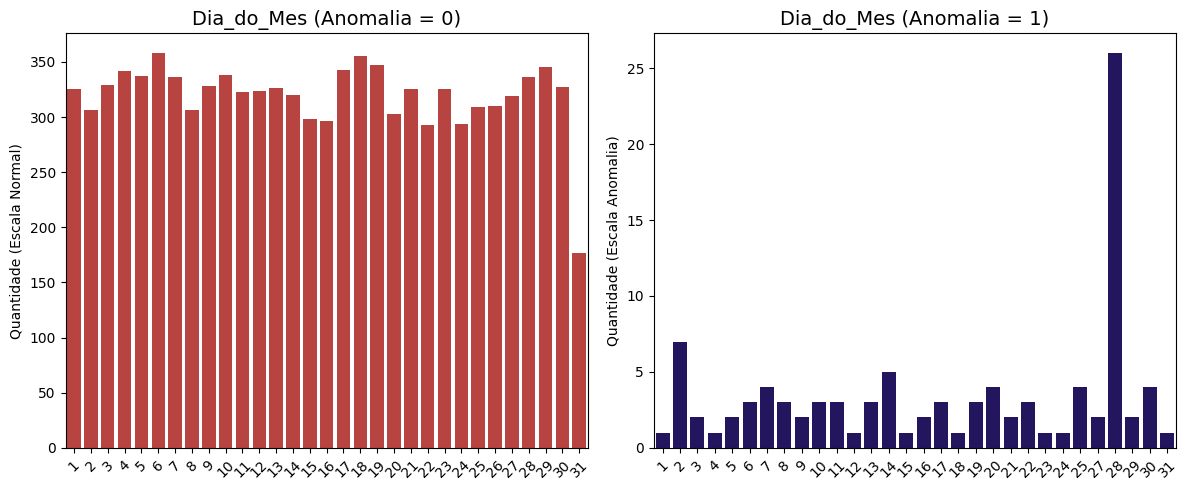

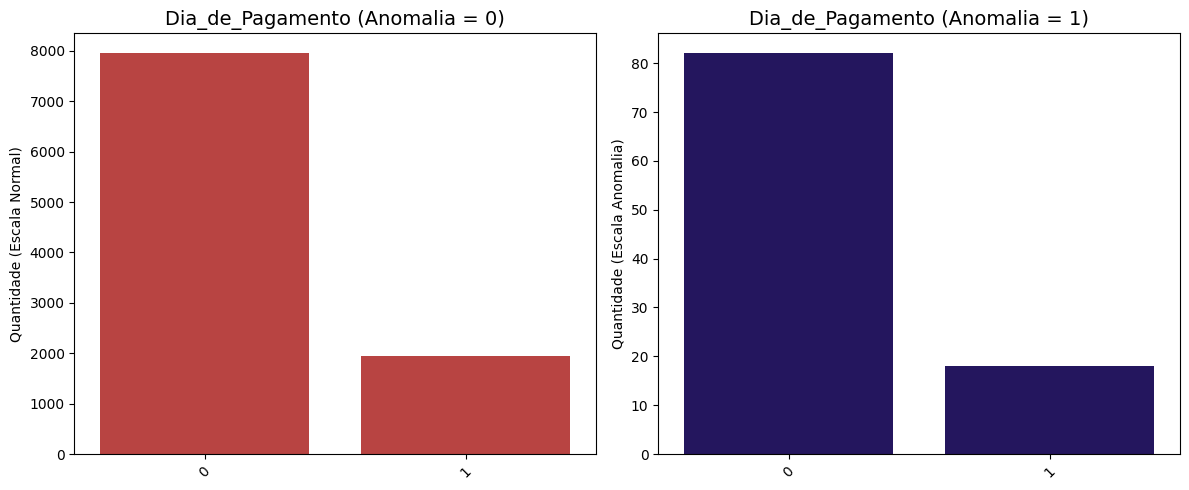

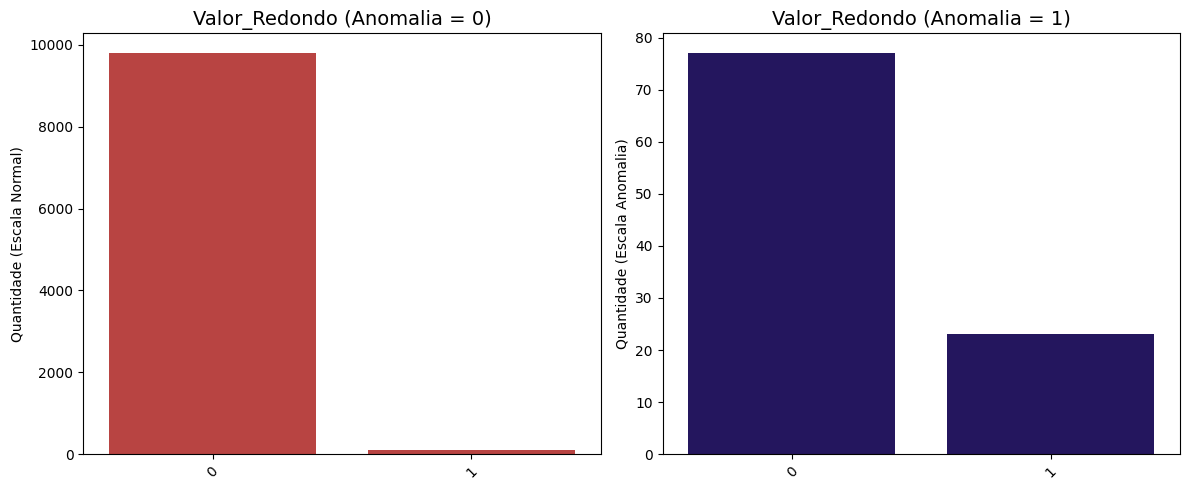

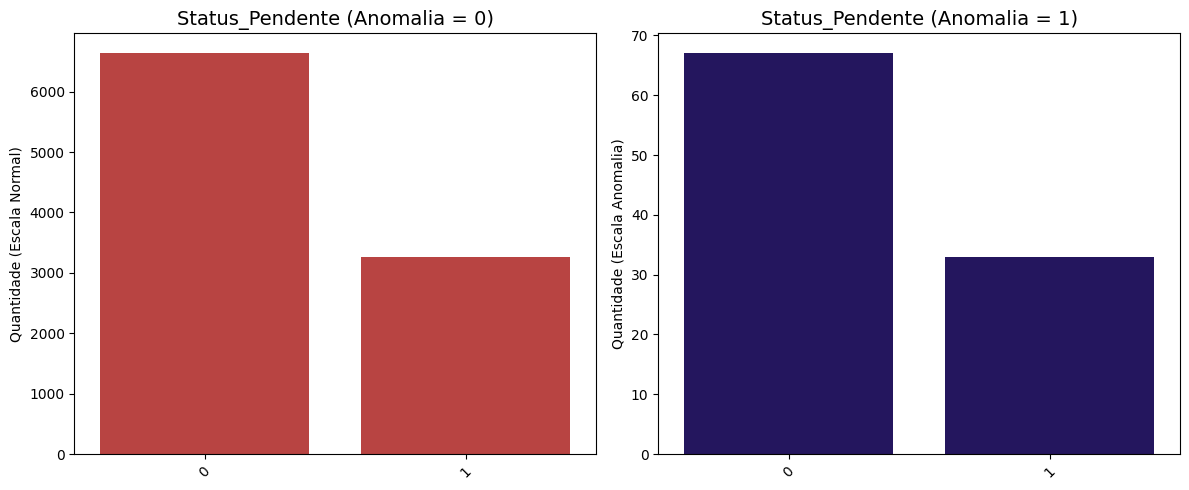

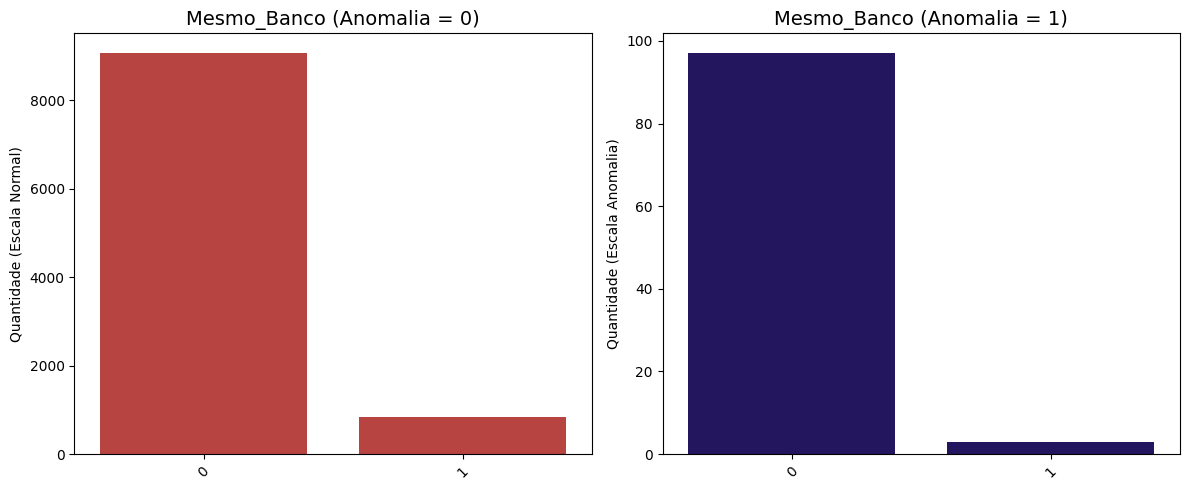

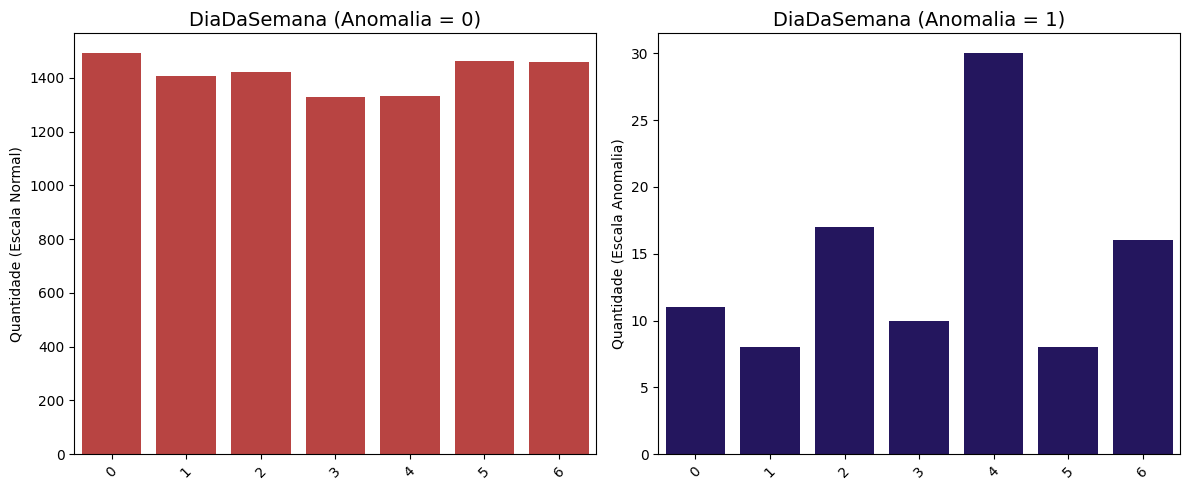

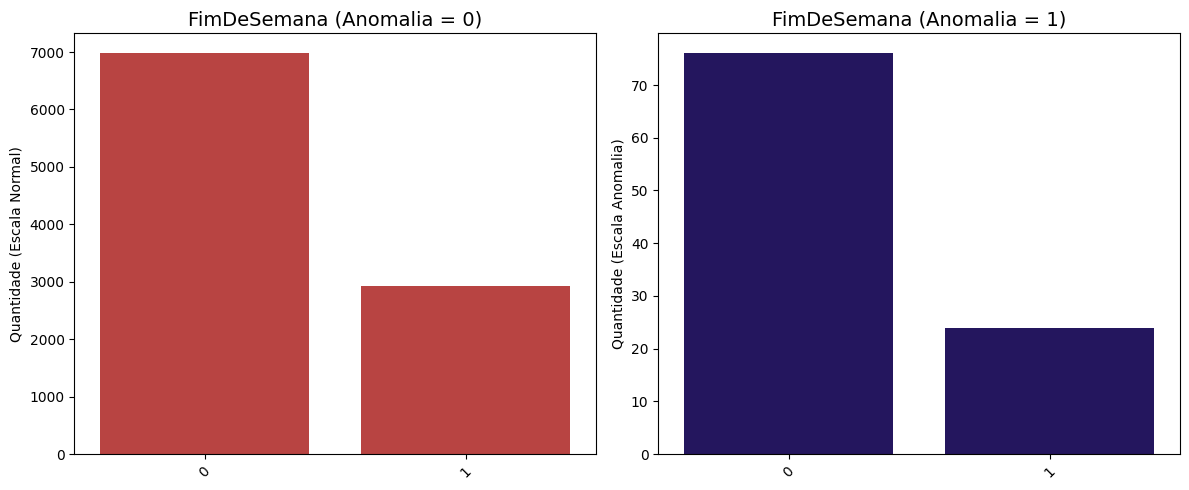

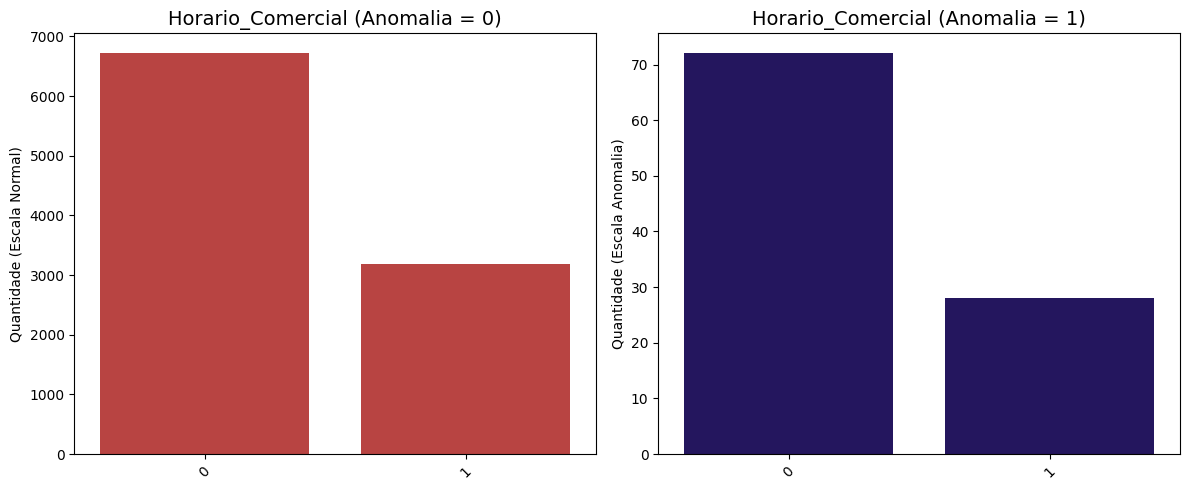

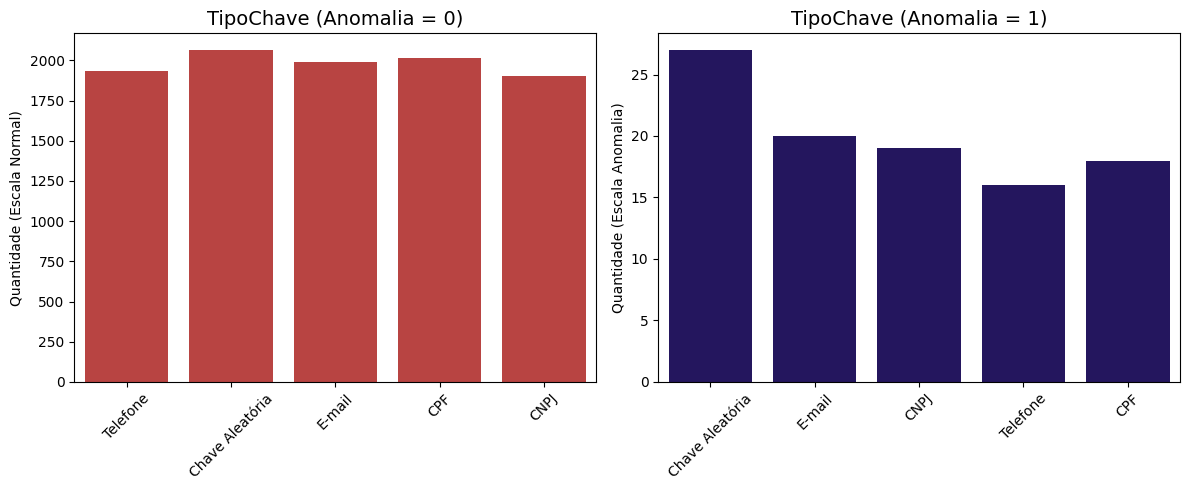

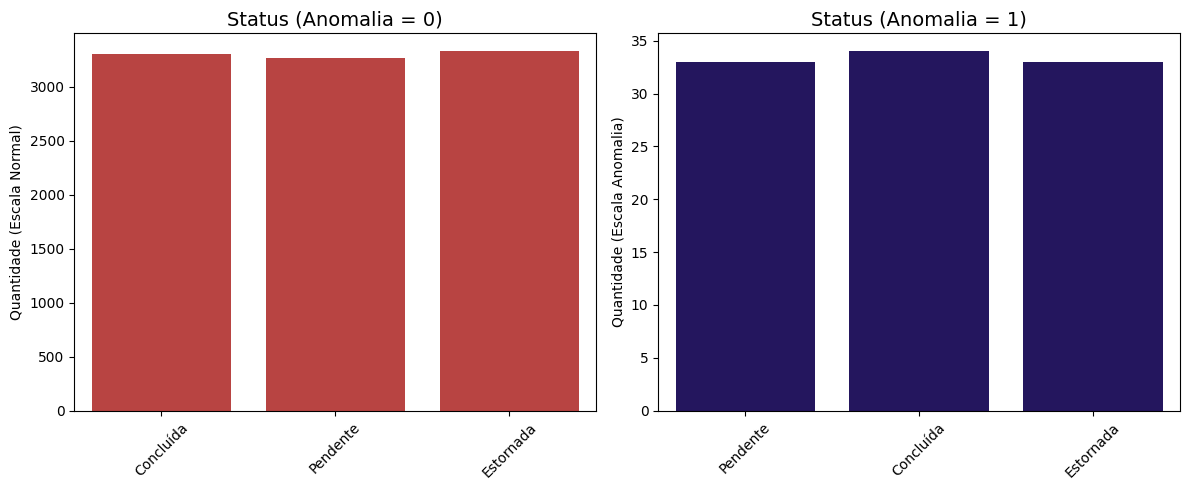

In [49]:
for coluna in var_cat:
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
    df_normal = df[df['Anomalia'] == 0]
    df_anomalo = df[df['Anomalia'] == 1]
    
    # --- GRÁFICO 1: ANOMALIA 0 (Esquerda) ---
    sns.countplot(
        data=df_normal, 
        x=coluna, 
        color="#cc312e", 
        ax=ax1           
    )
    ax1.set_title(f'{coluna} (Anomalia = 0)', fontsize=14)
    ax1.set_xlabel('')
    ax1.set_ylabel('Quantidade (Escala Normal)')
    ax1.tick_params(axis='x', rotation=45)
    
    # --- GRÁFICO 2: ANOMALIA 1 (Direita) ---
    sns.countplot(
        data=df_anomalo, 
        x=coluna, 
        color="#1d0a6a", 
        ax=ax2           
    )
    ax2.set_title(f'{coluna} (Anomalia = 1)', fontsize=14)
    ax2.set_xlabel('')
    ax2.set_ylabel('Quantidade (Escala Anomalia)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

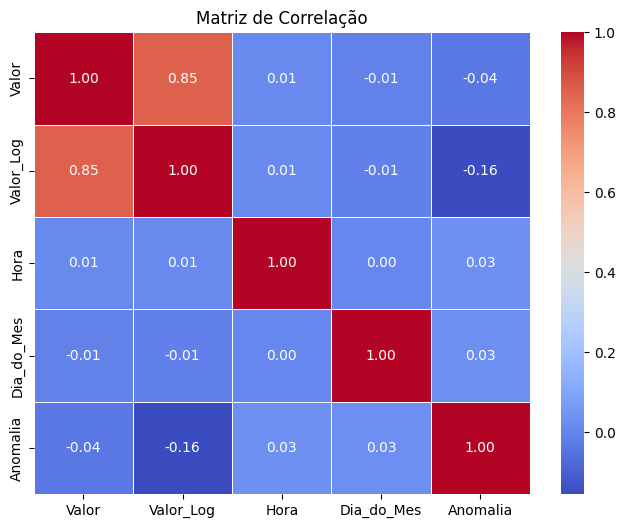

In [50]:
# 1. Matriz de Correlação (Heatmap)
# Selecionamos apenas algumas numéricas para o gráfico não ficar gigante
colunas_corr = ['Valor', 'Valor_Log', 'Hora', 'Dia_do_Mes', 'Anomalia']
matriz_corr = df[colunas_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

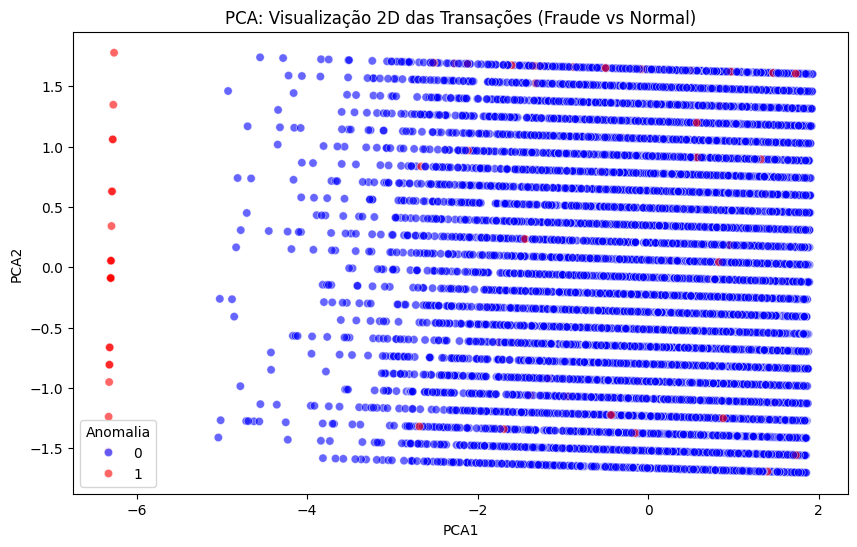

Variância explicada pelo PCA: 95.14%


In [51]:
# 2. PCA (Redução para 2 dimensões para podermos visualizar)
# Pegamos nas variáveis que já normalizaste na Etapa 1
features_pca = ['Valor_std', 'Valor_Log_std', 'Hora_std'] 

pca = PCA(n_components=2)
componentes = pca.fit_transform(df[features_pca])

df['PCA1'] = componentes[:, 0]
df['PCA2'] = componentes[:, 1]

# Gráfico do PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Anomalia', palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title('PCA: Visualização 2D das Transações (Fraude vs Normal)')
plt.show()

print(f"Variância explicada pelo PCA: {pca.explained_variance_ratio_.sum() * 100:.2f}%")